In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load cleaned dataset
df = pd.read_csv('../data/cleaned_customer_shopping_behavior.csv')
print("Data loaded successfully!")
print("Shape:", df.shape)
df.head()

Data loaded successfully!
Shape: (3900, 18)


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [4]:
# Check Previous Purchases column
print(df['Previous Purchases'].describe())
print("\nUnique values:", df['Previous Purchases'].nunique())

count    3900.000000
mean       25.351538
std        14.447125
min         1.000000
25%        13.000000
50%        25.000000
75%        38.000000
max        50.000000
Name: Previous Purchases, dtype: float64

Unique values: 50


In [5]:
# Create target column - Loyal Customer
median_purchases = df['Previous Purchases'].median()
print("Median Previous Purchases:", median_purchases)

df['Loyal_Customer'] = (df['Previous Purchases'] > median_purchases).astype(int)

print("\nLoyal Customer Distribution:")
print(df['Loyal_Customer'].value_counts())

Median Previous Purchases: 25.0

Loyal Customer Distribution:
Loyal_Customer
0    1965
1    1935
Name: count, dtype: int64


In [6]:
# Check which columns are text vs numbers
print("Text Columns:")
print(df.select_dtypes(include='object').columns.tolist())

print("\nNumber Columns:")
print(df.select_dtypes(include='number').columns.tolist())

Text Columns:
['Gender', 'Item Purchased', 'Category', 'Location', 'Size', 'Color', 'Season', 'Subscription Status', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Payment Method', 'Frequency of Purchases']

Number Columns:
['Customer ID', 'Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases', 'Loyal_Customer']


C:\Users\gayat\AppData\Local\Temp\ipykernel_15180\1482398828.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include='object').columns.tolist())


In [7]:
# Convert text columns to numbers using Label Encoding
le = LabelEncoder()

df['Gender_enc'] = le.fit_transform(df['Gender'])
df['Category_enc'] = le.fit_transform(df['Category'])
df['Season_enc'] = le.fit_transform(df['Season'])
df['Discount_enc'] = le.fit_transform(df['Discount Applied'])
df['Promo_enc'] = le.fit_transform(df['Promo Code Used'])
df['Payment_enc'] = le.fit_transform(df['Payment Method'])
df['Subscription_enc'] = le.fit_transform(df['Subscription Status'])

print("All text columns converted to numbers!")
df[['Gender','Gender_enc','Category','Category_enc']].head()

All text columns converted to numbers!


,Gender,Gender_enc,Category,Category_enc
0,Male,1,Clothing,1
1,Male,1,Clothing,1
2,Male,1,Clothing,1
3,Male,1,Footwear,2
4,Male,1,Clothing,1


In [8]:
# Select features (X) and target (y)
X = df[['Age', 'Gender_enc', 'Purchase Amount (USD)', 
        'Category_enc', 'Season_enc', 'Discount_enc', 
        'Promo_enc', 'Payment_enc', 'Subscription_enc',
        'Review Rating']]

y = df['Loyal_Customer']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
X.head()

Features (X) shape: (3900, 10)
Target (y) shape: (3900,)


,Age,Gender_enc,Purchase Amount (USD),Category_enc,Season_enc,Discount_enc,Promo_enc,Payment_enc,Subscription_enc,Review Rating
0,55,1,53,1,3,1,1,5,1,3.1
1,19,1,64,1,3,1,1,1,1,3.1
2,50,1,73,1,1,1,1,2,1,3.1
3,21,1,90,2,1,1,1,4,1,3.5
4,45,1,49,1,1,1,1,4,1,2.7


In [9]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (3120, 10)
Testing data shape: (780, 10)


In [10]:
# Train Random Forest Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [11]:
# Make predictions on test data
y_pred = model.predict(X_test)

print("Predictions made successfully!")
print("First 10 predictions:", y_pred[:10])
print("First 10 actual values:", y_test.values[:10])

Predictions made successfully!
First 10 predictions: [0 0 1 1 1 1 0 0 1 1]
First 10 actual values: [0 0 1 1 1 1 0 1 1 1]


In [12]:
# Check model accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", round(accuracy*100, 2), "%")

Model Accuracy: 49.36 %


In [13]:
# Detailed classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.51      0.51      0.51       402
           1       0.48      0.47      0.47       378

    accuracy                           0.49       780
   macro avg       0.49      0.49      0.49       780
weighted avg       0.49      0.49      0.49       780



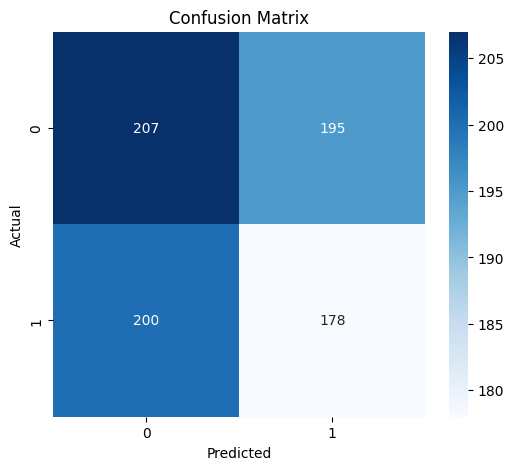

In [14]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [15]:
# Which factors matter most?
feature_importance = pd.Series(model.feature_importances_, 
                                index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print("Feature Importance:")
print(feature_importance)

Feature Importance:
Purchase Amount (USD)    0.251595
Age                      0.232935
Review Rating            0.199449
Payment_enc              0.101652
Category_enc             0.075372
Season_enc               0.070653
Gender_enc               0.023444
Subscription_enc         0.020678
Discount_enc             0.012409
Promo_enc                0.011814
dtype: float64


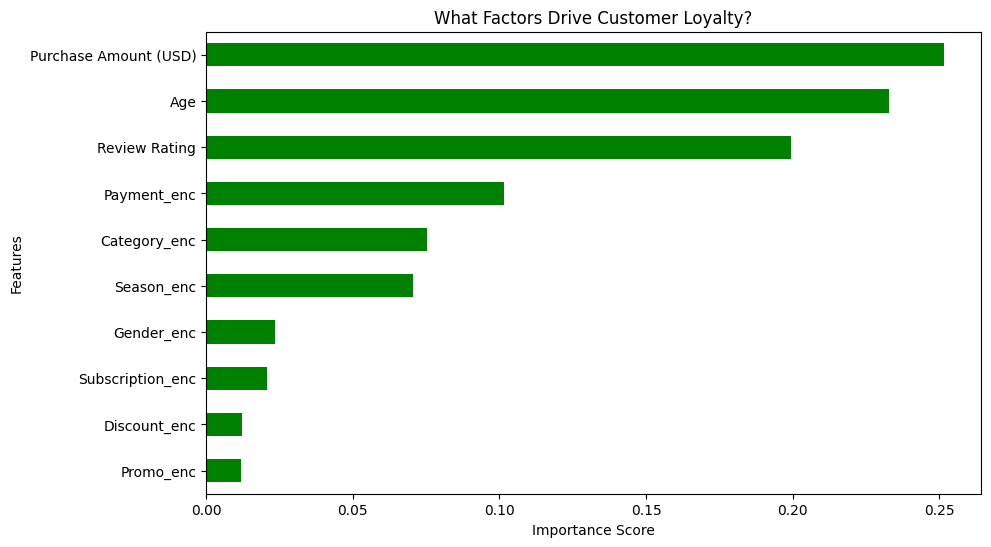

In [16]:
# Plot feature importance
plt.figure(figsize=(10,6))
feature_importance.plot(kind='barh', color='green')
plt.title('What Factors Drive Customer Loyalty?')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.gca().invert_yaxis()
plt.show()

In [17]:
import joblib

# Save the trained model
joblib.dump(model, '../data/loyalty_model.pkl')
print("Model saved successfully!")

Model saved successfully!
